In [1]:
!pip install scikit-image pydicom opencv-python

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from skimage.transform import resize
import matplotlib.pyplot as plt
import pydicom
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.layers import Input, Concatenate, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Dataset paths
dataset_path = "../input/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/"
train_images_dir = os.path.join(dataset_path, "stage_2_train/")
train_csv = os.path.join(dataset_path, "stage_2_train.csv")

# Load and preprocess train.csv
df = pd.read_csv(train_csv)
# Create 'id' and 'subtype'
df['id'] = df['ID'].apply(lambda st: "ID_" + st.split('_')[1])
df['subtype'] = df['ID'].apply(lambda st: st.split('_')[2])
df = df[["id", "subtype", "Label"]]


# Remove duplicates and fill missing values
df = df.drop_duplicates(subset=['id', 'subtype'])
df['Label'] = df['Label'].fillna(0)

# Pivot the data
df_pivot = df.pivot(index='id', columns='subtype', values='Label').reset_index()
print("Pivoted DataFrame shape:", df_pivot.shape)
print(df_pivot.head())

# Add file paths
df_pivot['file_path'] = df_pivot['id'].apply(lambda x: os.path.join(train_images_dir, f"{x}.dcm"))

# subset
df_subset = df_pivot.sample(n=5000, random_state=42)
print(f"Using {len(df_subset)} samples for training.")

# Preprocess DICOM images function
def preprocess_dicom(file_path, label, target_size=(224, 224)):
    try:
        dicom = pydicom.dcmread(file_path)
        img = dicom.pixel_array
        img = resize(img, target_size, mode="constant", anti_aliasing=True)
        img = np.expand_dims(img, axis=-1)
        img = np.repeat(img, 3, axis=-1)
        img = img / np.max(img) if np.max(img) > 0 else img
        return img, label
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None

images, labels = [], []
for _, row in df_subset.iterrows():
    img, lbl = preprocess_dicom(row['file_path'],
                                row[["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]].values)
    if img is not None:
        images.append(img)
        labels.append(lbl)

images = np.array(images)
labels = np.array(labels)
print("Preprocessed Images shape:", images.shape)
print("Preprocessed Labels shape:", labels.shape)

# Split data
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)


def create_ensemble_model(input_shape=(224, 224, 3), num_classes=6):
    # Input
    input_layer = Input(shape=input_shape)

    # EfficientNet Branch
    effnet_base = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=input_layer)
    effnet_base.trainable = False
    effnet_out = GlobalAveragePooling2D()(effnet_base.output)

    # ResNet Branch
    resnet_base = ResNet50(include_top=False, weights='imagenet', input_tensor=input_layer)
    resnet_base.trainable = False
    resnet_out = GlobalAveragePooling2D()(resnet_base.output)

    # Concatenate features
    merged = Concatenate()([effnet_out, resnet_out])
    dense = Dense(256, activation='relu')(merged)
    dropout = Dropout(0.5)(dense)
    output_layer = Dense(num_classes, activation='sigmoid')(dropout)

    # Model
    model = Model(inputs=input_layer, outputs=output_layer)

    # Compile
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# Create the ensemble model
ensemble_model = create_ensemble_model()

# Train
history = ensemble_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=3, batch_size=32)

# Save
ensemble_model.save('ensemble_model.h5')


2025-05-31 14:56:29.858143: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748703390.206553      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748703390.328620      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Pivoted DataFrame shape: (752803, 7)
subtype            id  any  epidural  intraparenchymal  intraventricular  \
0        ID_000012eaf    0         0                 0                 0   
1        ID_000039fa0    0         0                 0                 0   
2        ID_00005679d    0         0                 0                 0   
3        ID_00008ce3c    0         0                 0                 0   
4        ID_0000950d7    0         0                 0                 0   

subtype  subarachnoid  subdural  
0                   0         0  
1                   0         0  
2                   0         0  
3                   0         0  
4                   0         0  
Using 5000 samples for training.
Preprocessed Images shape: (5000, 224, 224, 3)
Preprocessed Labels shape: (5000, 6)


2025-05-31 14:59:11.756462: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 598s 5s/step - accuracy: 0.0867 - loss: 0.3752 - val_accuracy: 0.0000e+00 - val_loss: 0.2064
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 552s 4s/step - accuracy: 0.0226 - loss: 0.2288 - val_accuracy: 0.0000e+00 - val_loss: 0.2044
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 556s 4s/step - accuracy: 0.0135 - loss: 0.2079 - val_accuracy: 0.0000e+00 - val_loss: 0.2053


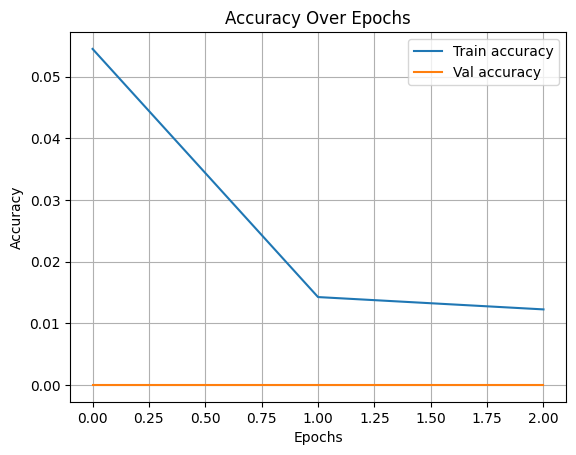

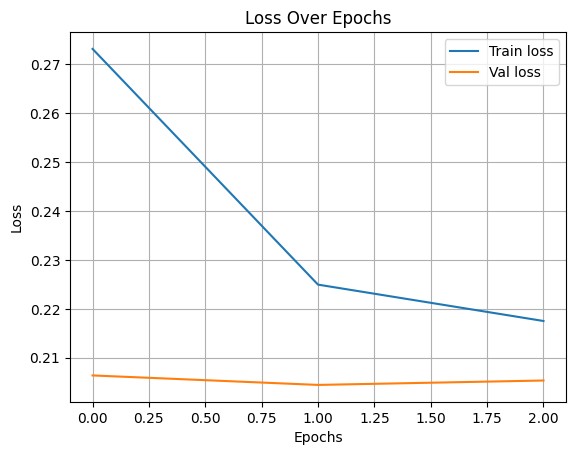

In [2]:
def plot_training_history(history):
    metrics = ['accuracy', 'loss']
    for metric in metrics:
        plt.plot(history.history[metric], label=f'Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'Val {metric}')
        plt.title(f'{metric.title()} Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel(metric.title())
        plt.legend()
        plt.grid(True)
        plt.show()

plot_training_history(history)

In [3]:
import pydicom
from skimage.transform import resize
import numpy as np

def load_dicom_image(path, target_size=(224, 224)):
    dicom = pydicom.dcmread(path)
    img = dicom.pixel_array
    img = resize(img, target_size, mode='constant', anti_aliasing=True)
    img = np.expand_dims(img, axis=-1)
    img = np.repeat(img, 3, axis=-1)
    img = img / np.max(img) if np.max(img) > 0 else img
    return np.expand_dims(img, axis=0)

# Predict
from tensorflow.keras.models import load_model

model = load_model('ensemble_model.h5')  # or 'efficientnet_model.h5'

image_path = "/kaggle/input/images/1-1.dcm"
image = load_dicom_image(image_path)
prediction = model.predict(image)

# Label names
labels = ["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]

# Print predictions
for i, label in enumerate(labels):
    print(f"{label}: {prediction[0][i]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
epidural: 0.0120
intraparenchymal: 0.0439
intraventricular: 0.0366
subarachnoid: 0.0713
subdural: 0.0491
any: 0.1570
